In [103]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from chicago_housing import config as C
from chicago_housing.data.load import load_training_data
from chicago_housing.data import clean
from chicago_housing.features import assemble
from chicago_housing.features.spatial import add_distance_to_loop

pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [106]:
df = load_training_data(columns=C.analysis_columns())   # read
sample = clean.build_analytic_sample(df)                # rows: scope + validity + log target
model_df = assemble.build_features(sample)              # columns: distance-to-Loop + school flag
model_df.head(3)

scope_filter:         413,289 ->   33,106 rows
drop_non_market: 33,106 -> 30,693
  always (PTAX/family):   1,747
  below $10,000 floor:  0
  entity + nominal/low:   670
  land-trust/title kept (market price): 1,247
analytic sample:                30,693 rows


,meta_sale_price,loc_property_city,meta_modeling_group,meta_year,ind_pin_is_multicard,ind_pin_is_prorated,meta_sale_seller_name,meta_sale_buyer_name,sv_outlier_reason1,sv_outlier_reason2,...,meta_nbhd_code,loc_census_tract_geoid,loc_latitude,loc_longitude,loc_x_3435,loc_y_3435,loc_chicago_community_area_name,log_sale_price,dist_to_loop_ft,no_rated_school_nearby
23,"235,000.000",CHICAGO,SF,2022,False,False,"MICHAEL J. SCHULTZ AND LEE ANN ZGOBICA,HEIRS A...",MARIA ESQUIVEL CONTRERAS,Non-person sale,NaN,...,72380,17031640300,41.780,-87.776,"1,136,228.800","1,862,970.810",CLEARING,12.367,"52,416.025",0
24,"250,000.000",CHICAGO,SF,2022,False,False,LAURA ABREGO,ROLANDO PRADES RIANO,NaN,NaN,...,72070,17031630400,41.796,-87.702,"1,156,334.671","1,868,748.376",GAGE PARK,12.429,"35,230.173",0
26,"230,000.000",CHICAGO,SF,2022,False,False,RODOLFO GARCIA-LANDA,DE SHENG CHEN,Statistical Anomaly,NaN,...,76060,17031840300,41.832,-87.681,"1,162,142.095","1,882,190.870",MCKINLEY PARK,12.346,"20,776.579",0


## 1. Scope filters
Countywide + all-types + 9-years  ->  Chicago / single-family / 2022-24 / single-card.
This also removes the bulk of the missingness (community area & ward only populate in-city).

In [107]:
# Appy filters for the city, single family and years
scoped = clean.scope_filter(df)

# confirm the filters landed as expected
print(scoped[C.YEAR_COL].value_counts().sort_index())
print(scoped[C.MODELING_GROUP_COL].value_counts())

scope_filter:         413,289 ->   33,106 rows
meta_year
2022    12909
2023    10546
2024     9651
Name: count, dtype: int64
meta_modeling_group
SF    33106
BB        0
MF        0
Name: count, dtype: int64


## 2. Sale validity — inspect the reasons BEFORE deciding what to drop
`sv_is_outlier` bundles *non-market transfers* (drop — different data-generating process) with 
*price-extreme but genuine* sales (keep for inference). Read the reason columns and calibrate 
`config.NON_ARMS_LENGTH_REASONS` to match the actual category strings printed below.

In [108]:
for col in C.SV_REASON_COLS:
    print(f'\n=== {col} ===')
    print(scoped[col].value_counts(dropna=True))


=== sv_outlier_reason1 ===
sv_outlier_reason1
Non-person sale               10527
Statistical Anomaly            5625
Short-term owner               2769
PTAX-203 Exclusion             1243
Low price                      1091
High price                      275
Family Sale                     206
Low price per square foot       194
High price per square foot      153
Name: count, dtype: int64

=== sv_outlier_reason2 ===
sv_outlier_reason2
Non-person sale               3360
Statistical Anomaly           2431
Low price per square foot      893
High price per square foot     140
Short-term owner                62
Family Sale                     46
PTAX-203 Exclusion              13
Raw price threshold              1
Low price                        1
Name: count, dtype: int64

=== sv_outlier_reason3 ===
sv_outlier_reason3
Non-person sale              519
Statistical Anomaly          445
PTAX-203 Exclusion           264
Short-term owner              50
Family Sale                    8
Pri

In [109]:
# Apply the split: drop non-arm's-length, keep price-extreme
scoped_valid = clean.drop_non_market(scoped)

drop_non_market: 33,106 -> 30,693
  always (PTAX/family):   1,747
  below $10,000 floor:  0
  entity + nominal/low:   670
  land-trust/title kept (market price): 1,247


## MD File to capture reasoning behind inclusion / exclusion of sale price logic

## 3. Column profile — missingness + degeneracy
A column can be 0% missing yet useless (one value in >95% of rows). `pct_modal` catches that.

In [110]:
candidate = (
    C.BLOCK_A_STRUCTURE
    + [c for c in C.BLOCK_B_LOCATION if c != 'dist_to_loop_ft']
    + C.DEMOGRAPHICS
)
prof = clean.profile_columns(scoped_valid, candidate)

(C.OUTPUTS / 'tables').mkdir(parents=True, exist_ok=True)
prof.to_csv(C.OUTPUTS / 'tables' / 'step0a_profile.csv', index=False)
prof

,column,role,dtype,pct_missing,n_unique,pct_modal,modal_value
0,acs5_median_income_household_past_year,acs5,float64,0.007,"1,417.000",0.005,"78,064.000"
1,acs5_percent_education_bachelor,acs5,float64,0.000,"1,453.000",0.005,0.243
2,acs5_percent_household_owner_occupied,acs5,float64,0.000,"1,455.000",0.005,0.823
3,char_porch,char,category,0.002,3.000,0.791,0
4,char_bldg_sf,char,float64,0.000,"2,987.000",0.011,"1,040.000"
5,char_land_sf,char,float64,0.000,"4,287.000",0.093,"3,750.000"
6,char_yrblt,char,float64,0.000,162.000,0.030,"1,923.000"
7,char_beds,char,float64,0.000,10.000,0.493,3.000
8,char_fbath,char,float64,0.000,8.000,0.670,1.000
9,char_gar1_size,char,category,0.000,8.000,0.532,3


## 4. Build the analytic sample + engineered feature
`build_analytic_sample` runs the canonical pipeline (scope -> validity -> log target). 
Then we add `dist_to_loop_ft` (our monocentric differentiator).

In [111]:
print('final analytic sample:', sample.shape)

final analytic sample: (30693, 41)


## 5. Distributions
### 5.1 Target — why we log

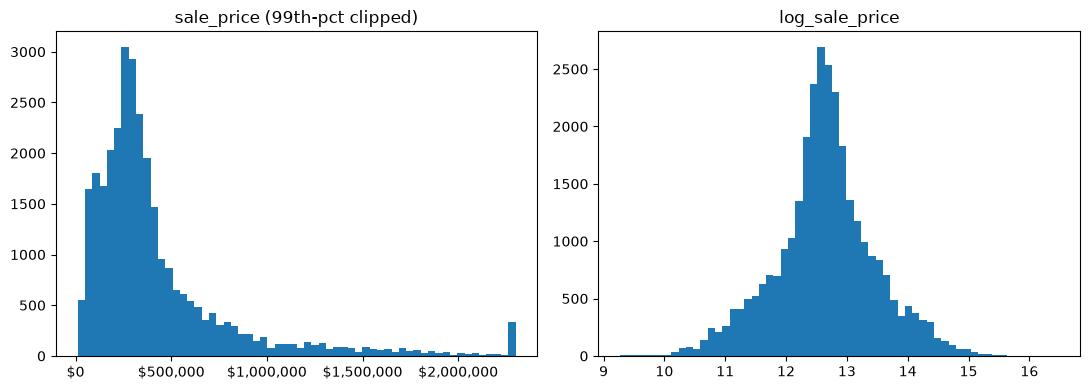

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(sample[C.TARGET_RAW].clip(upper=sample[C.TARGET_RAW].quantile(0.99)), bins=60)
axes[0].set_title('sale_price (99th-pct clipped)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
axes[1].hist(sample[C.TARGET], bins=60)
axes[1].set_title('log_sale_price')
plt.tight_layout(); plt.show()

### 5.2 Key predictors

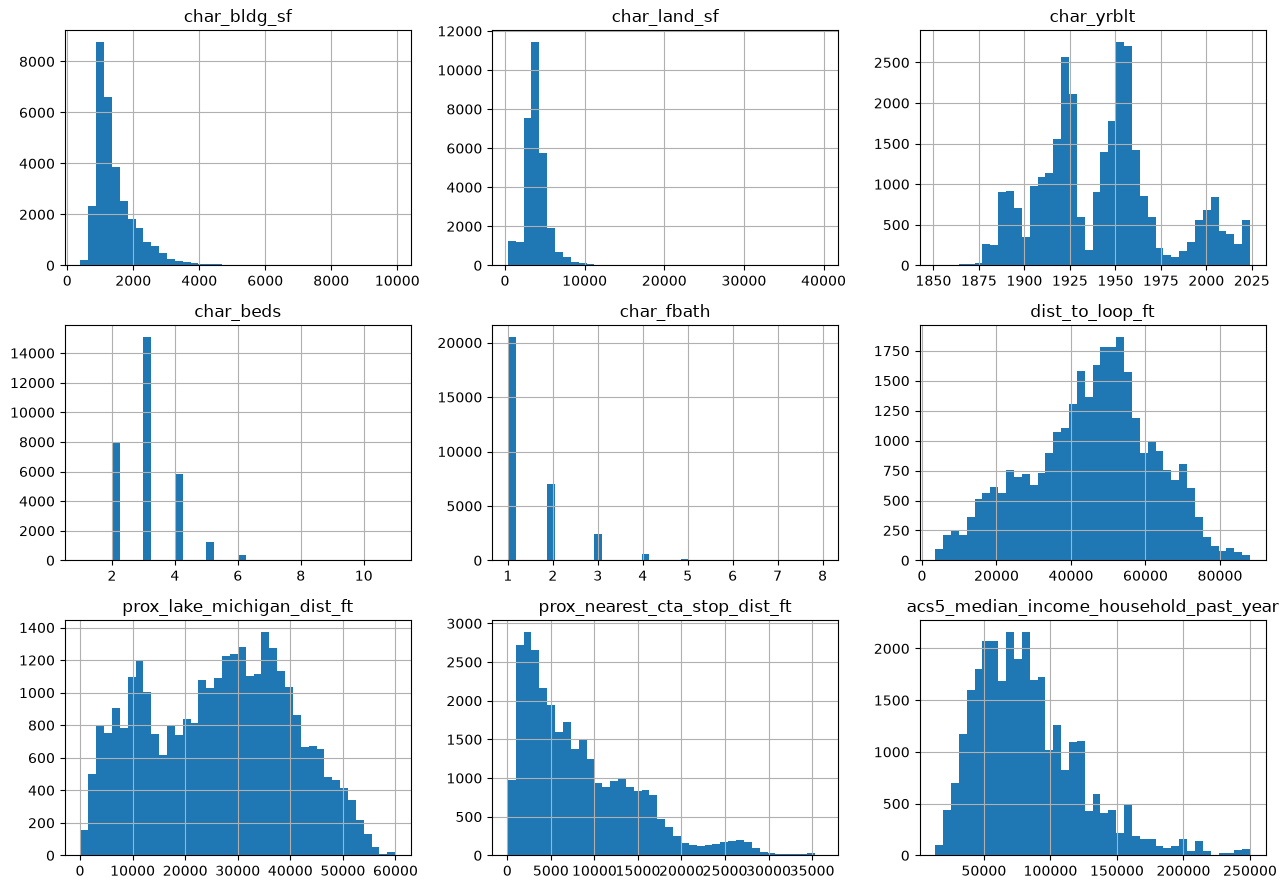

In [114]:
numeric = [
    'char_bldg_sf', 'char_land_sf', 'char_yrblt', 'char_beds', 'char_fbath',
    'dist_to_loop_ft', 'prox_lake_michigan_dist_ft', 'prox_nearest_cta_stop_dist_ft',
    'acs5_median_income_household_past_year',
]
model_df[numeric].hist(bins=40, figsize=(13, 9))
plt.tight_layout(); plt.show()

## 6. Outlier / sanity analysis
Two things: (a) a price-per-sqft sanity pass, (b) impossible-value checks. 
Remember we *retained* price-extreme sales on purpose — this is about spotting **data errors**, 
not trimming genuine tails.

In [115]:
model_df['price_per_sqft'] = model_df[C.TARGET_RAW] / model_df['char_bldg_sf'].replace(0, np.nan)
model_df['price_per_sqft'].describe(percentiles=[.01, .05, .5, .95, .99])

count   30,691.000
mean       274.027
std        161.186
min          5.597
1%          35.574
5%          65.148
50%        252.195
95%        577.842
99%        781.307
max      3,216.667
Name: price_per_sqft, dtype: float64

In [116]:
checks = {
    'sale_price <= 10k':   int((pd.to_numeric(model_df[C.TARGET_RAW]) <= 10_000).sum()),
    'char_bldg_sf <= 0':   int((model_df['char_bldg_sf'] <= 0).sum()),
    'char_beds == 0':      int((model_df['char_beds'] == 0).sum()),
    'char_yrblt < 1850':   int((model_df['char_yrblt'] < 1850).sum()),
    'price_per_sqft > 2000': int((model_df['price_per_sqft'] > 2000).sum()),
}
pd.Series(checks, name='n_rows')

sale_price <= 10k        0
char_bldg_sf <= 0        0
char_beds == 0           0
char_yrblt < 1850        0
price_per_sqft > 2000    4
Name: n_rows, dtype: int64

### 6.1 Price level by sale year
Motivates the **sale-year fixed effect**: 2022-24 rates moved, so price *levels* drift even within the window.

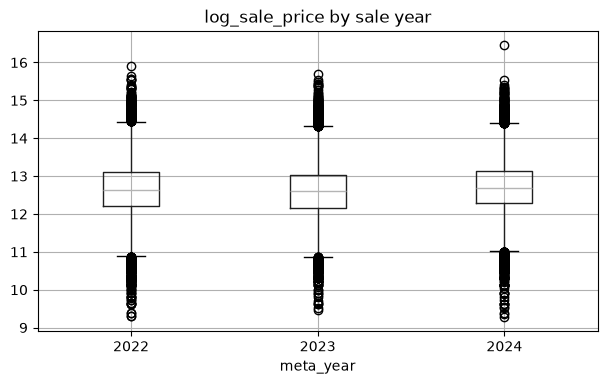

In [102]:
sample.boxplot(column=C.TARGET, by=C.YEAR_COL, figsize=(7, 4))
plt.title('log_sale_price by sale year'); plt.suptitle(''); plt.show()

## Next
1. **Calibrate** `config.NON_ARMS_LENGTH_REASONS` from the section-2 output.
2. Decide **school-rating** handling (~25% missing): impute vs complete-case.
3. Lock any sanity drops from section 6, then move to the modeling notebook (`11_inference_hedonic`).